## Neural Network

Applying a Neural Network approach merely on the MHAR feature set. 

In [44]:
import pandas as pd 
import numpy as np
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/RV_total.csv"
df = pd.read_csv(file_path)

# Convert "Date" column to datetime 
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_convert("Europe/Berlin")
df = df.sort_values("Date").set_index("Date")

df.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_intra_pos,RV_intra_neg,RV_overnight_pos,RV_overnight_neg,RV_overnight,RV_total,RV_total_pos,RV_total_neg,RQ,r_daily,log_RV_total,log_RV_intra
Date,,,,,,,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000066,0.000042,0.000000,0.000001,0.000001,0.000109,0.000066,0.000043,1.898579e-08,0.019734,-9.121878,-9.133686
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000058,0.000071,0.000029,0.000000,0.000029,0.000158,0.000087,0.000071,2.613017e-08,-0.000387,-8.755823,-8.957822
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000032,0.000036,0.000049,0.000000,0.000049,0.000117,0.000081,0.000036,7.450015e-09,0.004685,-9.056151,-9.602531
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000052,0.000057,0.000000,0.000008,0.000008,0.000117,0.000052,0.000065,1.545187e-08,-0.007108,-9.052878,-9.123543
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000053,0.000036,0.000000,0.000007,0.000007,0.000097,0.000053,0.000043,3.748493e-08,0.001214,-9.243673,-9.322462


In [46]:
# Create dedicated dataframe for baseline HAR
df_NN = df.sort_index().copy()

# Base RV series
rv = df_NN["RV_total"]

# HAR regressors available at time t
df_NN["RV_d"] = rv
df_NN["RV_w"] = rv.rolling(window=5).mean()
df_NN["RV_m"] = rv.rolling(window=22).mean()

# Forecast target (next day's RV)
df_NN["RV_target"] = rv.shift(-1)

In [48]:
# Keep only rows where all regressors and target are available
df_NN = df_NN.dropna(subset=["RV_d", "RV_w", "RV_m", "RV_target"])

print("First usable date:", df_NN.index.min())
print("Last usable date:", df_NN.index.max())
print("Number of usable observations:", len(df_NN))

First usable date: 1998-03-31 00:00:00+02:00
Last usable date: 2020-08-06 00:00:00+02:00
Number of usable observations: 5689


In [50]:
# Define split dates
train_end = "2012-12-31"
val_end   = "2015-12-31"

# Chronological split
df_train = df_NN.loc[:train_end]
df_val   = df_NN.loc[train_end:val_end]
df_test  = df_NN.loc[val_end:]

# Remove overlap at boundary (since slicing is inclusive)
df_val   = df_val.iloc[1:]
df_test  = df_test.iloc[1:]

# Print sizes
print("Train observations:", len(df_train))
print("Validation observations:", len(df_val))
print("Test observations:", len(df_test))

print("\nTrain period:", df_train.index.min(), "to", df_train.index.max())
print("Validation period:", df_val.index.min(), "to", df_val.index.max())
print("Test period:", df_test.index.min(), "to", df_test.index.max())

Train observations: 3745
Validation observations: 768
Test observations: 1176

Train period: 1998-03-31 00:00:00+02:00 to 2012-12-31 00:00:00+01:00
Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00


#### Implementation of Neural Network

In [53]:
from sklearn.preprocessing import StandardScaler

features = ["RV_d", "RV_w", "RV_m"]

scaler = StandardScaler()

# Fit ONLY on training data, then transform all splits
X_train = scaler.fit_transform(df_train[features])
X_val   = scaler.transform(df_val[features])
X_test  = scaler.transform(df_test[features])

# Targets are kept in original scale for interpretable MSE
y_train = df_train["RV_target"].values
y_val   = df_val["RV_target"].values
y_test  = df_test["RV_target"].values

print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)
print("X_test shape:",  X_test.shape)

X_train shape: (3745, 3)
X_val shape: (768, 3)
X_test shape: (1176, 3)


In [55]:
import torch
import torch.nn as nn

class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 4),        # Input layer -> Hidden layer 1 (4 neurons)
            nn.LeakyReLU(0.01),
            nn.Linear(4, 2),        # Hidden layer 1 -> Hidden layer 2 (2 neurons)
            nn.LeakyReLU(0.01),
            nn.Linear(2, 1)         # Hidden layer 2 -> Output (1 forecast)
        )
    
    def forward(self, x):
        return self.network(x)

# Instantiate and print the architecture
model = FeedForwardNN()
print(model)

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=4, out_features=2, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=2, out_features=1, bias=True)
  )
)


#### Step 3: Convert Data to PyTorch Tensors

In [58]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

# Wrap training data in a DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)

print("y_train_t shape:", y_train_t.shape)
print("y_val_t shape:  ", y_val_t.shape)
print("y_test_t shape: ", y_test_t.shape)

y_train_t shape: torch.Size([3745, 1])
y_val_t shape:   torch.Size([768, 1])
y_test_t shape:  torch.Size([1176, 1])


#### Step 4: Training Loop with Early Stopping

In [61]:
import copy

# Reinitialise model and optimizer
torch.manual_seed(42)
model     = FeedForwardNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Early stopping settings
patience      = 100
best_val_loss = float("inf")
best_weights  = None
epochs_no_improve = 0
max_epochs    = 500

train_losses = []
val_losses   = []

for epoch in range(max_epochs):
    # --- Training ---
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss        = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
    
    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss  = criterion(val_preds, y_val_t).item()
    
    train_losses.append(loss.item())
    val_losses.append(val_loss)
    
    # --- Early stopping check ---
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Restore best weights
model.load_state_dict(best_weights)
print(f"Best validation MSE: {best_val_loss:.6f}")

Best validation MSE: 0.000000


In [62]:
print("RV_target statistics:")
print(df_NN["RV_target"].describe())

print(f"\nBest validation MSE (full precision): {best_val_loss:.10f}")
print(f"Best validation RMSE: {best_val_loss**0.5:.10f}")

# Also check what the naive mean forecast would give as MSE
naive_mse = float(criterion(
    torch.full_like(y_val_t, y_train_t.mean()), 
    y_val_t
))
print(f"Naive mean forecast MSE: {naive_mse:.10f}")

RV_target statistics:
count    5.689000e+03
mean     1.519431e-04
std      2.469277e-04
min      1.319954e-07
25%      4.524784e-05
50%      8.389415e-05
75%      1.601697e-04
max      5.199071e-03
Name: RV_target, dtype: float64

Best validation MSE (full precision): 0.0000002855
Best validation RMSE: 0.0005343243
Naive mean forecast MSE: 0.0000000192


In [63]:
# Scale target using training mean and std
y_mean = y_train.mean()
y_std  = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled   = (y_val   - y_mean) / y_std
y_test_scaled  = (y_test  - y_mean) / y_std

# Recreate tensors with scaled targets
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val_scaled,   dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test_scaled,  dtype=torch.float32).unsqueeze(1)

print(f"Scaled y_train mean: {y_train_scaled.mean():.4f}")
print(f"Scaled y_train std:  {y_train_scaled.std():.4f}")
print(f"Scaled y_val mean:   {y_val_scaled.mean():.4f}")
print(f"Scaled y_val std:    {y_val_scaled.std():.4f}")

Scaled y_train mean: 0.0000
Scaled y_train std:  1.0000
Scaled y_val mean:   -0.2185
Scaled y_val std:    0.4832


In [64]:
# Recreate DataLoader with scaled targets
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)

# Reinitialise model and optimizer
torch.manual_seed(42)
model     = FeedForwardNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Early stopping settings
patience          = 100
best_val_loss     = float("inf")
best_weights      = None
epochs_no_improve = 0
max_epochs        = 500

train_losses = []
val_losses   = []

for epoch in range(max_epochs):
    # --- Training ---
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss        = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
    
    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss  = criterion(val_preds, y_val_t).item()
    
    train_losses.append(loss.item())
    val_losses.append(val_loss)
    
    # --- Early stopping check ---
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_weights      = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Restore best weights
model.load_state_dict(best_weights)
print(f"Best validation MSE (scaled): {best_val_loss:.6f}")
print(f"Best validation RMSE (scaled): {best_val_loss**0.5:.6f}")

Best validation MSE (scaled): 0.271313
Best validation RMSE (scaled): 0.520877


Neural Network Test MSE:  0.0000000632
Neural Network Test RMSE: 0.0002513997


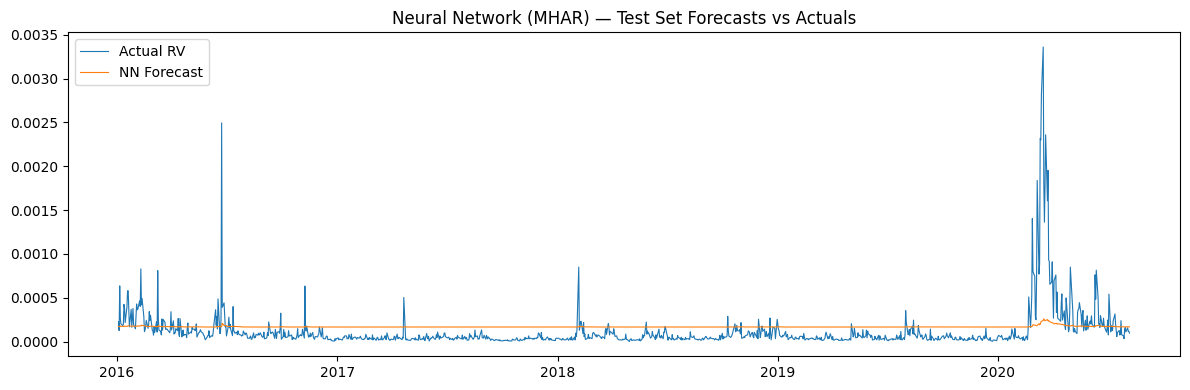

In [65]:
# Generate test set forecasts
model.eval()
with torch.no_grad():
    test_preds_scaled = model(X_test_t).numpy().flatten()

# Reverse the scaling to get forecasts in original RV units
test_preds = test_preds_scaled * y_std + y_mean

# Compute MSE in original units
mse_nn = np.mean((test_preds - y_test) ** 2)
rmse_nn = np.sqrt(mse_nn)

print(f"Neural Network Test MSE:  {mse_nn:.10f}")
print(f"Neural Network Test RMSE: {rmse_nn:.10f}")

# Plot forecasts vs actuals for a visual check
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df_test.index, y_test,      label="Actual RV",       linewidth=0.8)
plt.plot(df_test.index, test_preds,  label="NN Forecast",     linewidth=0.8)
plt.title("Neural Network (MHAR) — Test Set Forecasts vs Actuals")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
print("Test period forecast statistics:")
print(f"  Mean forecast:   {test_preds.mean():.6f}")
print(f"  Std forecast:    {test_preds.std():.6f}")
print(f"  Mean actual:     {y_test.mean():.6f}")
print(f"  Std actual:      {y_test.std():.6f}")
print(f"  Min forecast:    {test_preds.min():.6f}")
print(f"  Max forecast:    {test_preds.max():.6f}")

Test period forecast statistics:
  Mean forecast:   0.000169
  Std forecast:    0.000009
  Mean actual:     0.000119
  Std actual:      0.000253
  Min forecast:    0.000166
  Max forecast:    0.000260


In [69]:
# Redefine mean_train from training set
mean_train = df_train["RV_target"].mean()

# Out-of-sample R² for Neural Network
sse_test_nn    = np.sum((y_test - test_preds) ** 2)
sse_test_bench = np.sum((y_test - mean_train) ** 2)
r2_oos_nn      = 1 - (sse_test_nn / sse_test_bench)

print(f"Neural Network Test MSE:       {mse_nn:.10f}")
print(f"Neural Network Test OOS R²:    {r2_oos_nn:.6f}")
print(f"\nFor reference:")
print(f"Benchmark SSE (mean forecast): {sse_test_bench:.10f}")
print(f"Neural Network SSE:            {sse_test_nn:.10f}")

Neural Network Test MSE:       0.0000000632
Neural Network Test OOS R²:    0.054768

For reference:
Benchmark SSE (mean forecast): 0.0000786318
Neural Network SSE:            0.0000743253


In [71]:
import copy
import torch
import torch.nn as nn
import numpy as np

# Full dataset arrays for rolling window
X_all = df_NN[features].values
y_all = df_NN["RV_target"].values

# Index where test period starts in df_NN
test_start_idx = df_NN.index.get_loc(df_test.index[0])

# Rolling window settings
train_window = 2000
val_window   = 200
patience     = 100
max_epochs   = 500
rolling_preds = []

print(f"Total test observations to forecast: {len(df_test)}")
print(f"Starting rolling window forecast...\n")

for i, test_idx in enumerate(range(test_start_idx, test_start_idx + len(df_test))):
    
    # --- Define rolling windows ---
    train_start = test_idx - train_window - val_window
    val_start   = test_idx - val_window
    
    X_tr = X_all[train_start : val_start]
    y_tr = y_all[train_start : val_start]
    X_vl = X_all[val_start   : test_idx]
    y_vl = y_all[val_start   : test_idx]
    X_te = X_all[test_idx    : test_idx + 1]
    
    # --- Standardize features using training window stats ---
    x_mean = X_tr.mean(axis=0)
    x_std  = X_tr.std(axis=0)
    X_tr_s = (X_tr - x_mean) / x_std
    X_vl_s = (X_vl - x_mean) / x_std
    X_te_s = (X_te - x_mean) / x_std
    
    # --- Standardize target using training window stats ---
    y_mean = y_tr.mean()
    y_std  = y_tr.std()
    y_tr_s = (y_tr - y_mean) / y_std
    y_vl_s = (y_vl - y_mean) / y_std
    
    # --- Convert to tensors ---
    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_s, dtype=torch.float32).unsqueeze(1)
    X_vl_t = torch.tensor(X_vl_s, dtype=torch.float32)
    y_vl_t = torch.tensor(y_vl_s, dtype=torch.float32).unsqueeze(1)
    X_te_t = torch.tensor(X_te_s, dtype=torch.float32)
    
    # --- Initialise model ---
    torch.manual_seed(42)
    model     = FeedForwardNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    # Glorot initialization
    for layer in model.network:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
    
    # --- Training loop with early stopping ---
    best_val_loss     = float("inf")
    best_weights      = None
    epochs_no_improve = 0
    
    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_tr_t)
        loss  = criterion(preds, y_tr_t)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl_t), y_vl_t).item()
        
        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_weights      = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            break
    
    # --- Restore best weights and forecast ---
    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_te_t).item()
    
    # Reverse scaling
    pred = pred_scaled * y_std + y_mean
    rolling_preds.append(pred)
    
    # Progress update every 100 steps
    if (i + 1) % 100 == 0:
        print(f"  Completed {i+1}/{len(df_test)} forecasts")

print("\nRolling window forecast complete!")
rolling_preds = np.array(rolling_preds)

Total test observations to forecast: 1176
Starting rolling window forecast...

  Completed 100/1176 forecasts
  Completed 200/1176 forecasts
  Completed 300/1176 forecasts
  Completed 400/1176 forecasts
  Completed 500/1176 forecasts
  Completed 600/1176 forecasts
  Completed 700/1176 forecasts
  Completed 800/1176 forecasts
  Completed 900/1176 forecasts
  Completed 1000/1176 forecasts
  Completed 1100/1176 forecasts

Rolling window forecast complete!


Rolling window forecast statistics:
  Mean forecast:   0.000149
  Std forecast:    0.000040
  Mean actual:     0.000119
  Std actual:      0.000253
  Min forecast:    -0.000221
  Max forecast:    0.000238

Rolling NN Test MSE:    0.0000000658
Rolling NN OOS R²:      0.016607


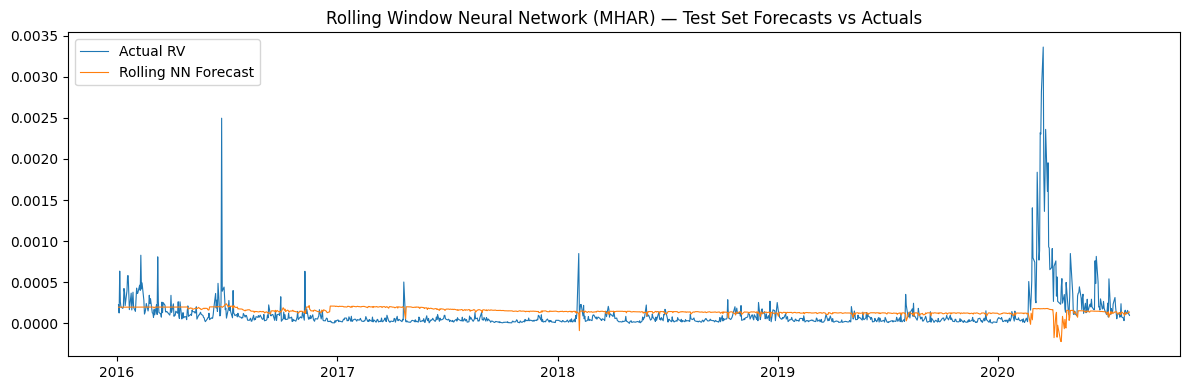

In [73]:
# Forecast statistics
print("Rolling window forecast statistics:")
print(f"  Mean forecast:   {rolling_preds.mean():.6f}")
print(f"  Std forecast:    {rolling_preds.std():.6f}")
print(f"  Mean actual:     {y_test.mean():.6f}")
print(f"  Std actual:      {y_test.std():.6f}")
print(f"  Min forecast:    {rolling_preds.min():.6f}")
print(f"  Max forecast:    {rolling_preds.max():.6f}")

# MSE and OOS R²
mse_nn_rolling = np.mean((rolling_preds - y_test) ** 2)
sse_nn_rolling = np.sum((rolling_preds - y_test) ** 2)
sse_bench      = np.sum((y_test - mean_train) ** 2)
r2_oos_nn_rolling = 1 - (sse_nn_rolling / sse_bench)

print(f"\nRolling NN Test MSE:    {mse_nn_rolling:.10f}")
print(f"Rolling NN OOS R²:      {r2_oos_nn_rolling:.6f}")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(df_test.index, y_test,         label="Actual RV",          linewidth=0.8)
plt.plot(df_test.index, rolling_preds,  label="Rolling NN Forecast", linewidth=0.8)
plt.title("Rolling Window Neural Network (MHAR) — Test Set Forecasts vs Actuals")
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
import copy
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

# Full dataset arrays
X_all = df_NN[features].values
y_all = df_NN["RV_target"].values
dates_all = df_NN.index

# Combine validation and test into one evaluation window
df_eval_nn = pd.concat([df_val, df_test])

expanding_preds = []
expanding_actuals = []
expanding_dates = []

for current_date in tqdm(df_eval_nn.index):
    
    # --- Expanding window: all data strictly before current_date ---
    mask = dates_all < current_date
    X_tr = X_all[mask]
    y_tr = y_all[mask]
    
    # --- Use last 200 observations as validation for early stopping ---
    X_tr_only = X_tr[:-200]
    y_tr_only = y_tr[:-200]
    X_vl      = X_tr[-200:]
    y_vl      = y_tr[-200:]
    
    # --- Standardize using training statistics ---
    x_mean = X_tr_only.mean(axis=0)
    x_std  = X_tr_only.std(axis=0)
    X_tr_s = (X_tr_only - x_mean) / x_std
    X_vl_s = (X_vl      - x_mean) / x_std
    
    # Current date features for forecast
    X_te   = df_NN.loc[[current_date], features].values
    X_te_s = (X_te - x_mean) / x_std
    
    # --- Standardize target ---
    y_mean    = y_tr_only.mean()
    y_std     = y_tr_only.std()
    y_tr_s    = (y_tr_only - y_mean) / y_std
    y_vl_s    = (y_vl      - y_mean) / y_std
    
    # --- Convert to tensors ---
    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_s, dtype=torch.float32).unsqueeze(1)
    X_vl_t = torch.tensor(X_vl_s, dtype=torch.float32)
    y_vl_t = torch.tensor(y_vl_s, dtype=torch.float32).unsqueeze(1)
    X_te_t = torch.tensor(X_te_s, dtype=torch.float32)
    
    # --- Initialise model with Glorot initialization ---
    torch.manual_seed(42)
    model     = FeedForwardNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    for layer in model.network:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
    
    # --- Training loop with early stopping ---
    best_val_loss     = float("inf")
    best_weights      = None
    epochs_no_improve = 0
    
    for epoch in range(500):
        model.train()
        optimizer.zero_grad()
        preds = model(X_tr_t)
        loss  = criterion(preds, y_tr_t)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl_t), y_vl_t).item()
        
        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_weights      = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            break
    
    # --- Restore best weights and forecast ---
    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_te_t).item()
    
    # Reverse scaling
    pred = pred_scaled * y_std + y_mean
    
    # Replace negative forecasts with minimum training RV
    min_train_rv = y_tr_only.min()
    pred = max(pred, min_train_rv)
    
    expanding_preds.append(pred)
    expanding_actuals.append(float(df_NN.loc[current_date, "RV_target"]))
    expanding_dates.append(current_date)

print("\nExpanding window forecast complete!")
expanding_preds    = np.array(expanding_preds)
expanding_actuals  = np.array(expanding_actuals)

100%|███████████████████████████████████████| 1944/1944 [03:14<00:00,  9.98it/s]


Expanding window forecast complete!


In [77]:
# Forecast statistics
print("Expanding window NN forecast statistics:")
print(f"  Mean forecast:   {expanding_preds.mean():.6f}")
print(f"  Std forecast:    {expanding_preds.std():.6f}")
print(f"  Mean actual:     {expanding_actuals.mean():.6f}")
print(f"  Std actual:      {expanding_actuals.std():.6f}")
print(f"  Min forecast:    {expanding_preds.min():.6f}")
print(f"  Max forecast:    {expanding_preds.max():.6f}")

# Split into validation and test
n_val = len(df_val)
preds_val  = expanding_preds[:n_val]
preds_test = expanding_preds[n_val:]
act_val    = expanding_actuals[:n_val]
act_test   = expanding_actuals[n_val:]

# MSE
mse_val_nn  = np.mean((preds_val  - act_val)  ** 2)
mse_test_nn = np.mean((preds_test - act_test) ** 2)

# OOS R²
sse_val_nn    = np.sum((preds_val  - act_val)  ** 2)
sse_test_nn   = np.sum((preds_test - act_test) ** 2)
sse_val_bench  = np.sum((act_val  - mean_train) ** 2)
sse_test_bench = np.sum((act_test - mean_train) ** 2)

r2_oos_val_nn  = 1 - (sse_val_nn  / sse_val_bench)
r2_oos_test_nn = 1 - (sse_test_nn / sse_test_bench)

print(f"\nValidation MSE:    {mse_val_nn:.10f}")
print(f"Test MSE:          {mse_test_nn:.10f}")
print(f"\nOOS R² Validation: {r2_oos_val_nn:.6f}")
print(f"OOS R² Test:       {r2_oos_test_nn:.6f}")

# Summary table
print("\n--- Summary ---")
print(f"{'Model':<25} {'OOS R² Val':>12} {'OOS R² Test':>12}")
print(f"{'HAR':<25} {0.3966:>12.4f} {0.6634:>12.4f}")
print(f"{'Neural Network':<25} {r2_oos_val_nn:>12.4f} {r2_oos_test_nn:>12.4f}")

Expanding window NN forecast statistics:
  Mean forecast:   0.000154
  Std forecast:    0.000030
  Mean actual:     0.000117
  Std actual:      0.000212
  Min forecast:    0.000000
  Max forecast:    0.000227

Validation MSE:    0.0000000189
Test MSE:          0.0000000613

OOS R² Validation: 0.016331
OOS R² Test:       0.083597

--- Summary ---
Model                       OOS R² Val  OOS R² Test
HAR                             0.3966       0.6634
Neural Network                  0.0163       0.0836


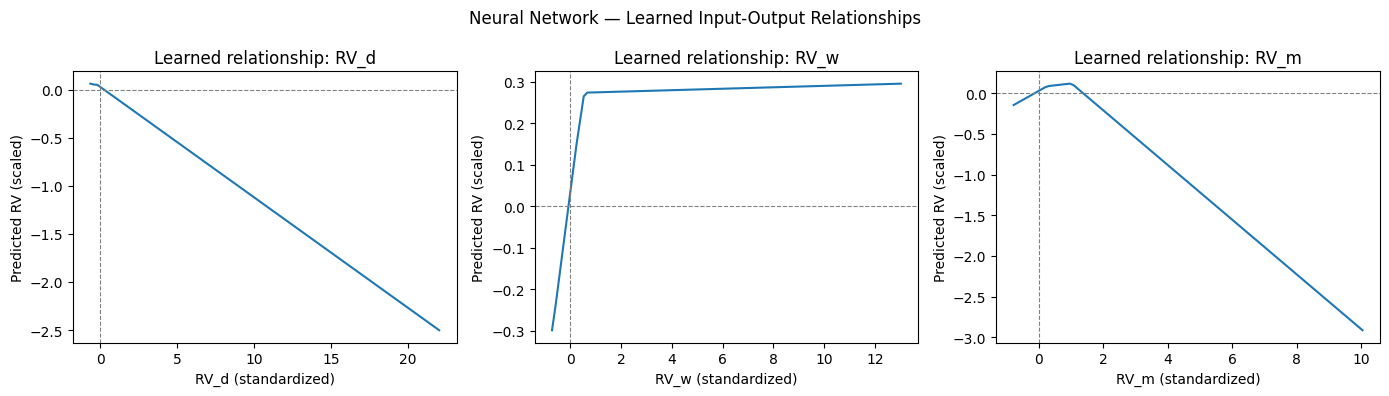

In [79]:
import matplotlib.pyplot as plt

model.eval()
results = {}

for j, feat in enumerate(features):
    # Create a grid of values for this feature
    grid = np.linspace(X_tr_s[:, j].min(), 
                       X_tr_s[:, j].max(), 100)
    
    # Hold other features at their mean (zero after scaling)
    X_grid = np.zeros((100, 3), dtype=np.float32)
    X_grid[:, j] = grid
    
    with torch.no_grad():
        preds_grid = model(torch.tensor(X_grid)).numpy().flatten()
    
    results[feat] = (grid, preds_grid)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, features):
    grid, preds_grid = results[feat]
    ax.plot(grid, preds_grid)
    ax.set_title(f"Learned relationship: {feat}")
    ax.set_xlabel(f"{feat} (standardized)")
    ax.set_ylabel("Predicted RV (scaled)")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("Neural Network — Learned Input-Output Relationships")
plt.tight_layout()
plt.show()

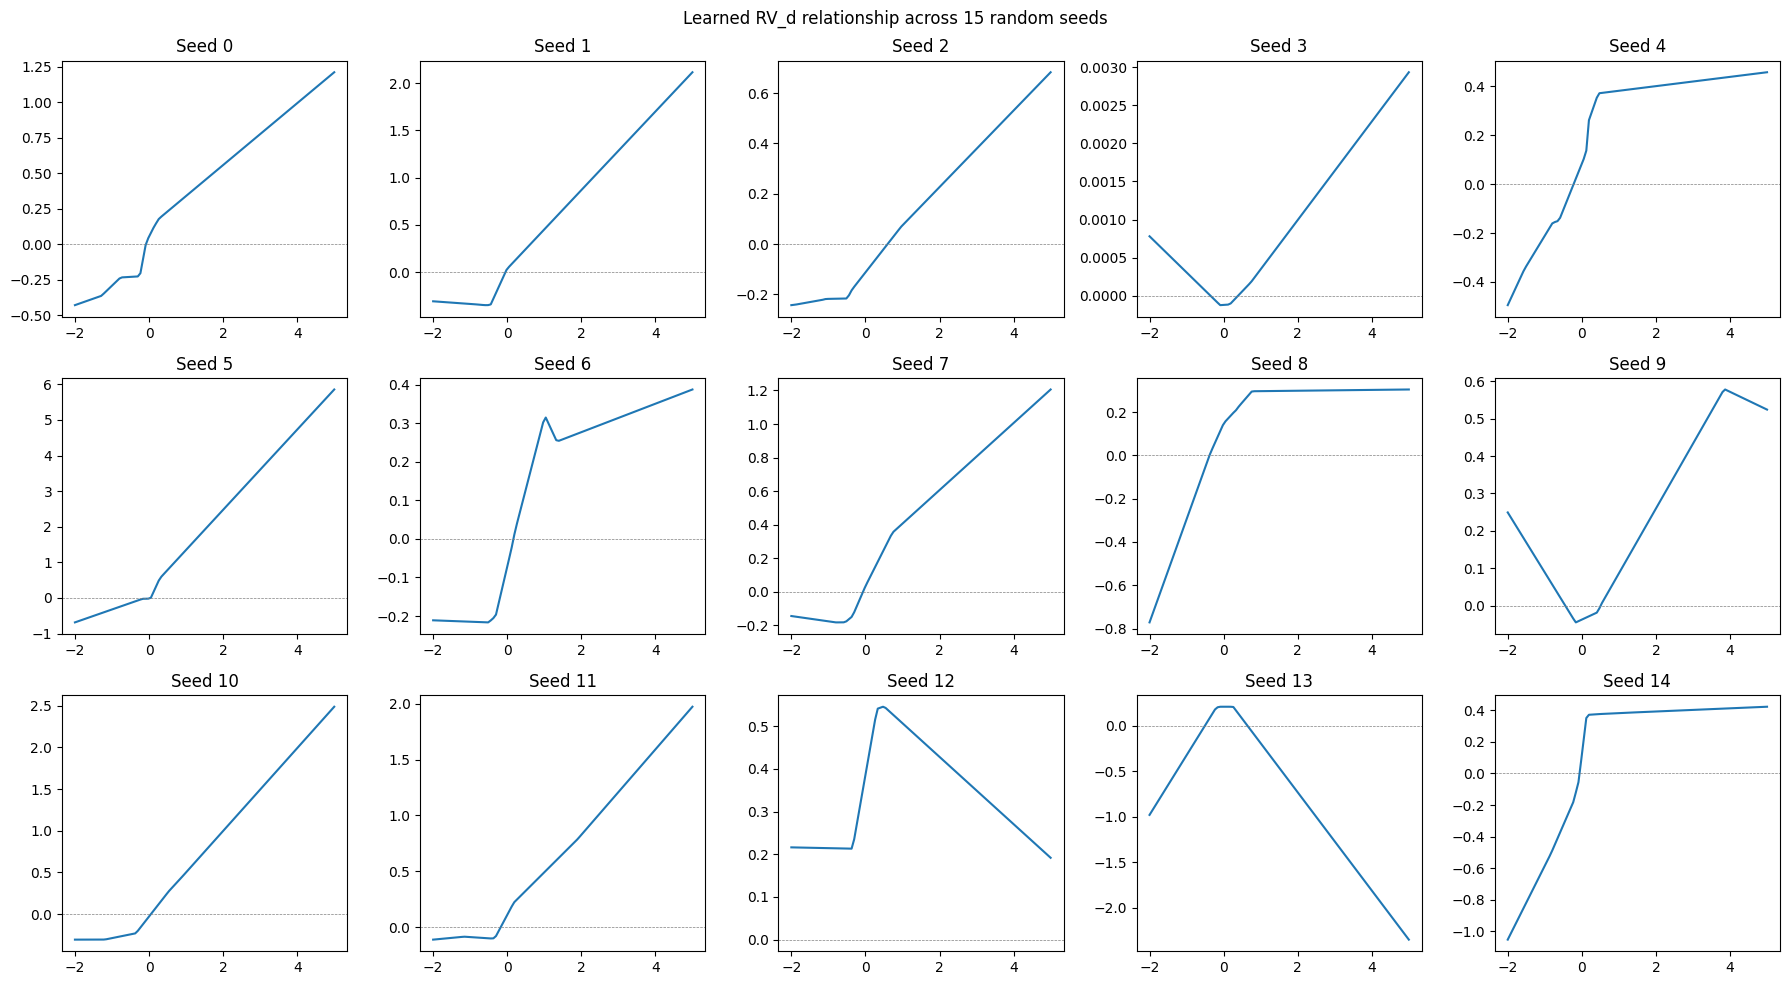

In [81]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for seed in range(15):
    # Train a fresh network with this seed
    torch.manual_seed(seed)
    test_model = FeedForwardNN()
    test_opt   = torch.optim.Adam(test_model.parameters(), lr=0.001)
    
    for layer in test_model.network:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
    
    # Train on full scaled training data
    for epoch in range(300):
        test_model.train()
        test_opt.zero_grad()
        preds = test_model(X_train_t)
        loss  = criterion(preds, y_train_t)
        loss.backward()
        test_opt.step()
    
    # Plot learned relationship for RV_d only
    grid = np.linspace(-2, 5, 100)
    X_grid = np.zeros((100, 3), dtype=np.float32)
    X_grid[:, 0] = grid
    
    test_model.eval()
    with torch.no_grad():
        preds_grid = test_model(torch.tensor(X_grid)).numpy().flatten()
    
    row, col = seed // 5, seed % 5
    axes[row, col].plot(grid, preds_grid)
    axes[row, col].set_title(f"Seed {seed}")
    axes[row, col].axhline(0, color="gray", linestyle="--", linewidth=0.5)

plt.suptitle("Learned RV_d relationship across 15 random seeds")
plt.tight_layout()
plt.show()

In [83]:
# Train 100 networks with different seeds, select best 10 by validation MSE
n_networks = 100
n_ensemble = 10
network_val_losses = []
network_weights = []

print("Training 100 networks...")

for seed in tqdm(range(n_networks)):
    torch.manual_seed(seed)
    m = FeedForwardNN()
    opt = torch.optim.Adam(m.parameters(), lr=0.001)
    
    for layer in m.network:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
    
    best_val   = float("inf")
    best_w     = None
    no_improve = 0
    
    for epoch in range(500):
        m.train()
        opt.zero_grad()
        loss = criterion(m(X_train_t), y_train_t)
        loss.backward()
        opt.step()
        
        m.eval()
        with torch.no_grad():
            val_loss = criterion(m(X_val_t), y_val_t).item()
        
        if val_loss < best_val:
            best_val = val_loss
            best_w   = copy.deepcopy(m.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        
        if no_improve >= patience:
            break
    
    network_val_losses.append(best_val)
    network_weights.append(best_w)

# Select best 10 networks by validation MSE
best_indices = np.argsort(network_val_losses)[:n_ensemble]
print(f"\nBest 10 validation MSEs:")
for i in best_indices:
    print(f"  Seed {i:3d}: {network_val_losses[i]:.6f}")

# Generate ensemble forecast on test set
ensemble_preds = []

for i in best_indices:
    m = FeedForwardNN()
    m.load_state_dict(network_weights[i])
    m.eval()
    with torch.no_grad():
        pred_scaled = m(X_test_t).numpy().flatten()
    pred = pred_scaled * y_std + y_mean
    ensemble_preds.append(pred)

# Average across ensemble
ensemble_preds = np.array(ensemble_preds)
final_preds    = ensemble_preds.mean(axis=0)

# Replace negative forecasts
min_train_rv  = y_train.min()
final_preds   = np.maximum(final_preds, min_train_rv)

# Compute OOS R²
sse_test_ens   = np.sum((final_preds - y_test) ** 2)
sse_test_bench = np.sum((y_test - mean_train) ** 2)
r2_oos_ens     = 1 - (sse_test_ens / sse_test_bench)

print(f"\nEnsemble forecast statistics:")
print(f"  Mean forecast: {final_preds.mean():.6f}")
print(f"  Std forecast:  {final_preds.std():.6f}")
print(f"  Mean actual:   {y_test.mean():.6f}")
print(f"  Std actual:    {y_test.std():.6f}")

print(f"\n--- Results ---")
print(f"{'Model':<25} {'OOS R² Test':>12}")
print(f"{'HAR':<25} {0.6634:>12.4f}")
print(f"{'NN Ensemble':<25} {r2_oos_ens:>12.4f}")

Training 100 networks...


100%|█████████████████████████████████████████| 100/100 [00:19<00:00,  5.09it/s]


Best 10 validation MSEs:
  Seed  21: 0.165711
  Seed  75: 0.166134
  Seed  28: 0.166693
  Seed  79: 0.166908
  Seed  76: 0.167364
  Seed  40: 0.168058
  Seed  60: 0.168244
  Seed   4: 0.169114
  Seed  34: 0.169703
  Seed  29: 0.169813

Ensemble forecast statistics:
  Mean forecast: 0.000091
  Std forecast:  0.000094
  Mean actual:   0.000119
  Std actual:    0.000253

--- Results ---
Model                      OOS R² Test
HAR                             0.6634
NN Ensemble                     0.4318


In [85]:
# Let us time a single day with 100 networks to get an accurate estimate
import time

start = time.time()

# Take the first expanding window as a test
mask = dates_all < df_eval_nn.index[0]
X_tr_test = X_all[mask]
y_tr_test = y_all[mask]

X_tr_only = X_tr_test[:-200]
y_tr_only = y_tr_test[:-200]
X_vl_test = X_tr_test[-200:]
y_vl_test = y_tr_test[-200:]

x_mean = X_tr_only.mean(axis=0)
x_std  = X_tr_only.std(axis=0)
X_tr_s = (X_tr_only - x_mean) / x_std
X_vl_s = (X_vl_test - x_mean) / x_std

y_mean_t = y_tr_only.mean()
y_std_t  = y_tr_only.std()
y_tr_s   = (y_tr_only - y_mean_t) / y_std_t
y_vl_s   = (y_vl_test - y_mean_t) / y_std_t

X_tr_t_loop = torch.tensor(X_tr_s, dtype=torch.float32)
y_tr_t_loop = torch.tensor(y_tr_s, dtype=torch.float32).unsqueeze(1)
X_vl_t_loop = torch.tensor(X_vl_s, dtype=torch.float32)
y_vl_t_loop = torch.tensor(y_vl_s, dtype=torch.float32).unsqueeze(1)

val_losses_test = []
weights_test    = []

for seed in range(100):
    torch.manual_seed(seed)
    m   = FeedForwardNN()
    opt = torch.optim.Adam(m.parameters(), lr=0.001)
    
    for layer in m.network:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
    
    best_val   = float("inf")
    best_w     = None
    no_improve = 0
    
    for epoch in range(500):
        m.train()
        opt.zero_grad()
        loss = criterion(m(X_tr_t_loop), y_tr_t_loop)
        loss.backward()
        opt.step()
        
        m.eval()
        with torch.no_grad():
            val_loss = criterion(m(X_vl_t_loop), y_vl_t_loop).item()
        
        if val_loss < best_val:
            best_val   = val_loss
            best_w     = copy.deepcopy(m.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        
        if no_improve >= patience:
            break
    
    val_losses_test.append(best_val)
    weights_test.append(best_w)

elapsed = time.time() - start
total_estimate = elapsed * len(df_eval_nn) / 60

print(f"Time for one day with 100 networks: {elapsed:.1f} seconds")
print(f"Estimated total time: {total_estimate:.0f} minutes")

Time for one day with 100 networks: 16.0 seconds
Estimated total time: 518 minutes


In [87]:
import copy
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

# Full dataset arrays
X_all     = df_NN[features].values
y_all     = df_NN["RV_target"].values
dates_all = df_NN.index

# Settings
n_networks  = 10
n_ensemble  = 10
patience_ew = 25
max_epochs  = 500

expanding_ensemble_preds   = []
expanding_ensemble_actuals = []
expanding_ensemble_dates   = []

print(f"Running expanding window ensemble ({n_networks} networks per day)...")
print(f"Test observations to forecast: {len(df_test)}\n")

for current_date in tqdm(df_test.index):
    
    # --- Expanding window: all data strictly before current_date ---
    mask     = dates_all < current_date
    X_tr     = X_all[mask]
    y_tr     = y_all[mask]
    
    # --- Carve out last 200 observations as validation ---
    X_tr_only = X_tr[:-200]
    y_tr_only = y_tr[:-200]
    X_vl      = X_tr[-200:]
    y_vl      = y_tr[-200:]
    
    # --- Standardize features ---
    x_mean = X_tr_only.mean(axis=0)
    x_std  = X_tr_only.std(axis=0)
    X_tr_s = (X_tr_only - x_mean) / x_std
    X_vl_s = (X_vl      - x_mean) / x_std
    
    # Current date features for forecast
    X_te   = df_NN.loc[[current_date], features].values
    X_te_s = (X_te - x_mean) / x_std
    
    # --- Standardize target ---
    y_mean_ew = y_tr_only.mean()
    y_std_ew  = y_tr_only.std()
    y_tr_s    = (y_tr_only - y_mean_ew) / y_std_ew
    y_vl_s    = (y_vl      - y_mean_ew) / y_std_ew
    
    # --- Convert to tensors ---
    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_s, dtype=torch.float32).unsqueeze(1)
    X_vl_t = torch.tensor(X_vl_s, dtype=torch.float32)
    y_vl_t = torch.tensor(y_vl_s, dtype=torch.float32).unsqueeze(1)
    X_te_t = torch.tensor(X_te_s, dtype=torch.float32)
    
    # --- Train ensemble of n_networks networks ---
    day_val_losses = []
    day_weights    = []
    
    for seed in range(n_networks):
        torch.manual_seed(seed)
        m   = FeedForwardNN()
        opt = torch.optim.Adam(m.parameters(), lr=0.001)
        
        for layer in m.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)
        
        best_val   = float("inf")
        best_w     = None
        no_improve = 0
        
        for epoch in range(max_epochs):
            m.train()
            opt.zero_grad()
            loss = criterion(m(X_tr_t), y_tr_t)
            loss.backward()
            opt.step()
            
            m.eval()
            with torch.no_grad():
                val_loss = criterion(m(X_vl_t), y_vl_t).item()
            
            if val_loss < best_val:
                best_val   = val_loss
                best_w     = copy.deepcopy(m.state_dict())
                no_improve = 0
            else:
                no_improve += 1
            
            if no_improve >= patience_ew:
                break
        
        day_val_losses.append(best_val)
        day_weights.append(best_w)
    
    # --- Select best n_ensemble networks by validation MSE ---
    best_idx = np.argsort(day_val_losses)[:n_ensemble]
    
    # --- Generate ensemble forecast ---
    day_preds = []
    for i in best_idx:
        m = FeedForwardNN()
        m.load_state_dict(day_weights[i])
        m.eval()
        with torch.no_grad():
            pred_scaled = m(X_te_t).item()
        pred = pred_scaled * y_std_ew + y_mean_ew
        day_preds.append(pred)
    
    # Average across ensemble
    final_pred = np.mean(day_preds)
    
    # Replace negative forecasts with minimum training RV
    min_train_rv = y_tr_only.min()
    final_pred   = max(final_pred, min_train_rv)
    
    expanding_ensemble_preds.append(final_pred)
    expanding_ensemble_actuals.append(float(df_NN.loc[current_date, "RV_target"]))
    expanding_ensemble_dates.append(current_date)

print("\nExpanding window ensemble forecast complete!")
expanding_ensemble_preds   = np.array(expanding_ensemble_preds)
expanding_ensemble_actuals = np.array(expanding_ensemble_actuals)

Running expanding window ensemble (10 networks per day)...
Test observations to forecast: 1176



100%|███████████████████████████████████████| 1176/1176 [28:39<00:00,  1.46s/it]


Expanding window ensemble forecast complete!


Expanding window ENSEMBLE forecast statistics:
  Mean forecast:   0.000142
  Std forecast:    0.000127
  Mean actual:     0.000119
  Std actual:      0.000253
  Min forecast:    0.000086
  Max forecast:    0.001596

Expanding Window Ensemble Test MSE:    0.0000000297
Expanding Window Ensemble OOS R²:      0.555309

--- Full Results Summary ---
Model                                OOS R² Test
------------------------------------------------
HAR (expanding window)                    0.6634
NN Single seed (fixed window)             0.0548
NN Ensemble (fixed window)                0.4318
NN Single seed (rolling window)           0.0166
NN Single seed (expanding window)         0.0836
NN Ensemble (expanding window)            0.5553


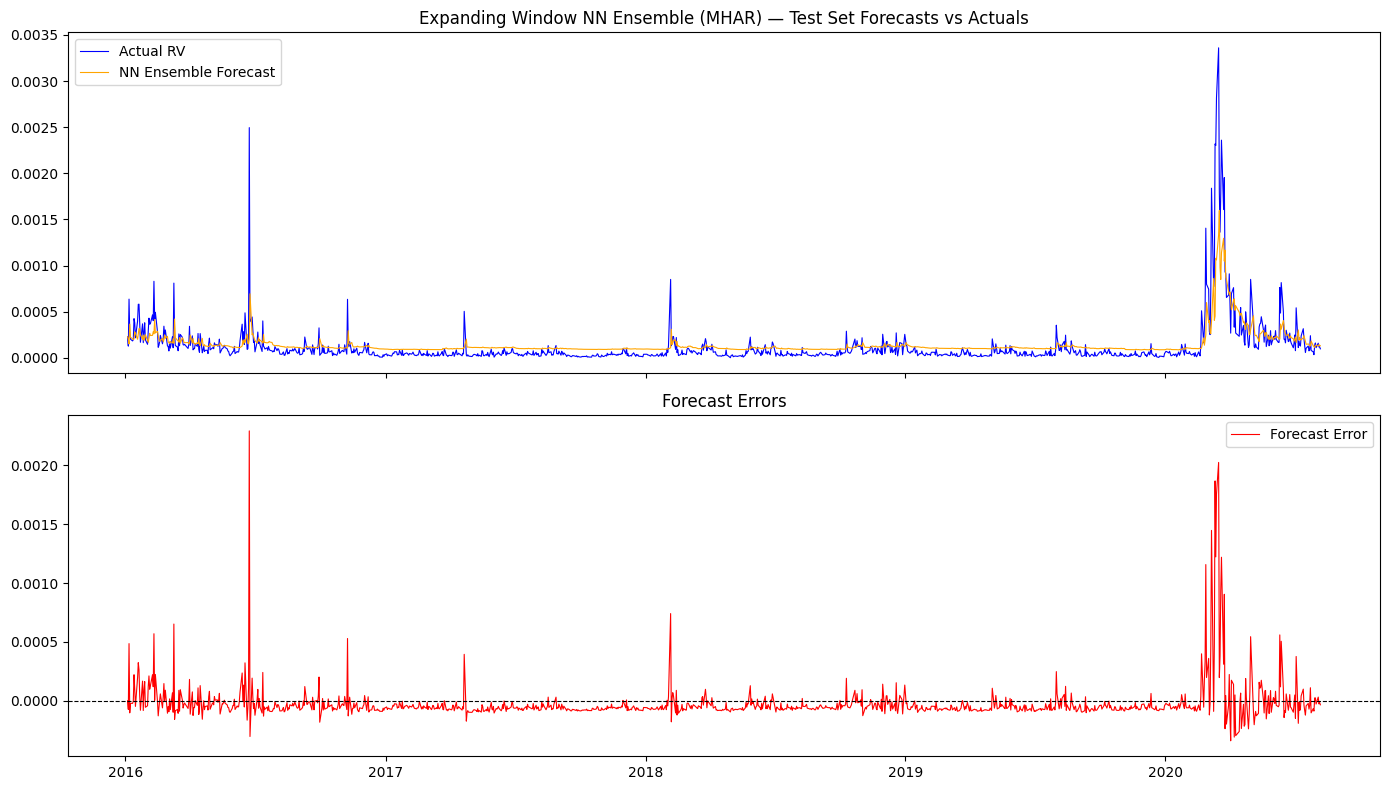

In [89]:
# Forecast statistics
print("Expanding window ENSEMBLE forecast statistics:")
print(f"  Mean forecast:   {expanding_ensemble_preds.mean():.6f}")
print(f"  Std forecast:    {expanding_ensemble_preds.std():.6f}")
print(f"  Mean actual:     {expanding_ensemble_actuals.mean():.6f}")
print(f"  Std actual:      {expanding_ensemble_actuals.std():.6f}")
print(f"  Min forecast:    {expanding_ensemble_preds.min():.6f}")
print(f"  Max forecast:    {expanding_ensemble_preds.max():.6f}")

# OOS R²
sse_test_ens_exp   = np.sum((expanding_ensemble_preds - expanding_ensemble_actuals) ** 2)
sse_test_bench_exp = np.sum((expanding_ensemble_actuals - mean_train) ** 2)
r2_oos_ens_exp     = 1 - (sse_test_ens_exp / sse_test_bench_exp)

mse_ens_exp = np.mean((expanding_ensemble_preds - expanding_ensemble_actuals) ** 2)

print(f"\nExpanding Window Ensemble Test MSE:    {mse_ens_exp:.10f}")
print(f"Expanding Window Ensemble OOS R²:      {r2_oos_ens_exp:.6f}")

# Full summary table
print("\n--- Full Results Summary ---")
print(f"{'Model':<35} {'OOS R² Test':>12}")
print(f"{'-'*48}")
print(f"{'HAR (expanding window)':<35} {0.6634:>12.4f}")
print(f"{'NN Single seed (fixed window)':<35} {0.0548:>12.4f}")
print(f"{'NN Ensemble (fixed window)':<35} {0.4318:>12.4f}")
print(f"{'NN Single seed (rolling window)':<35} {0.0166:>12.4f}")
print(f"{'NN Single seed (expanding window)':<35} {0.0836:>12.4f}")
print(f"{'NN Ensemble (expanding window)':<35} {r2_oos_ens_exp:>12.4f}")

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_test.index, expanding_ensemble_actuals, 
             label="Actual RV", linewidth=0.8, color="blue")
axes[0].plot(df_test.index, expanding_ensemble_preds,  
             label="NN Ensemble Forecast", linewidth=0.8, color="orange")
axes[0].set_title("Expanding Window NN Ensemble (MHAR) — Test Set Forecasts vs Actuals")
axes[0].legend()

axes[1].plot(df_test.index, expanding_ensemble_actuals - expanding_ensemble_preds,
             label="Forecast Error", linewidth=0.8, color="red")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Forecast Errors")
axes[1].legend()

plt.tight_layout()
plt.show()